Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')


Mounted at /content/drive/


Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import os

Set paths:

In [ ]:
project_path="/content/drive/MyDrive/Linear-Regression-Project"

raw_path=f"{project_path}/Data/Raw/train.csv"
processed_path=f"{project_path}/Data/Processed/processed_data.csv"
viz_path=f"{project_path}/Visualizations/"

Check for Visualization folder

In [ ]:
os.makedirs(viz_path, exist_ok=True)

Load Dataset

In [ ]:
df=pd.read_csv(raw_path)

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Overview

In [ ]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


Exploratory Data Analysis
Histogram (Sale Price Distribution)

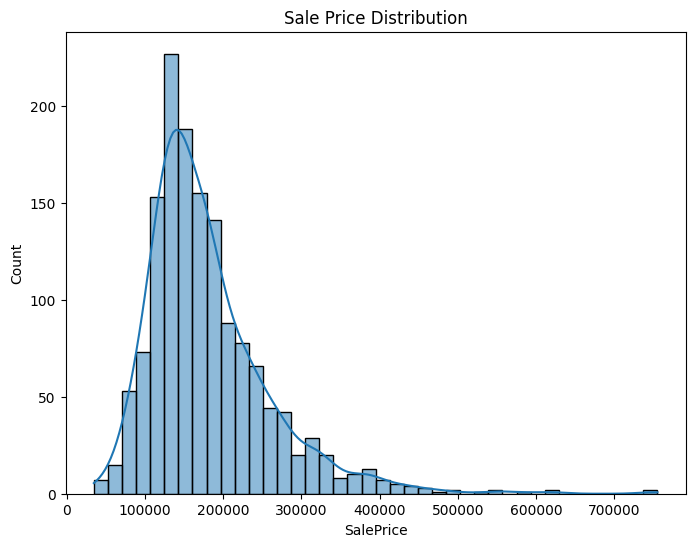

In [ ]:
plt.figure(figsize=(8,6))
sns.histplot(df["SalePrice"], bins=40, kde=True)

plt.title("Sale Price Distribution")

plt.savefig(viz_path+"saleprice_histogram.png")

plt.show()

Correlation Heatmap

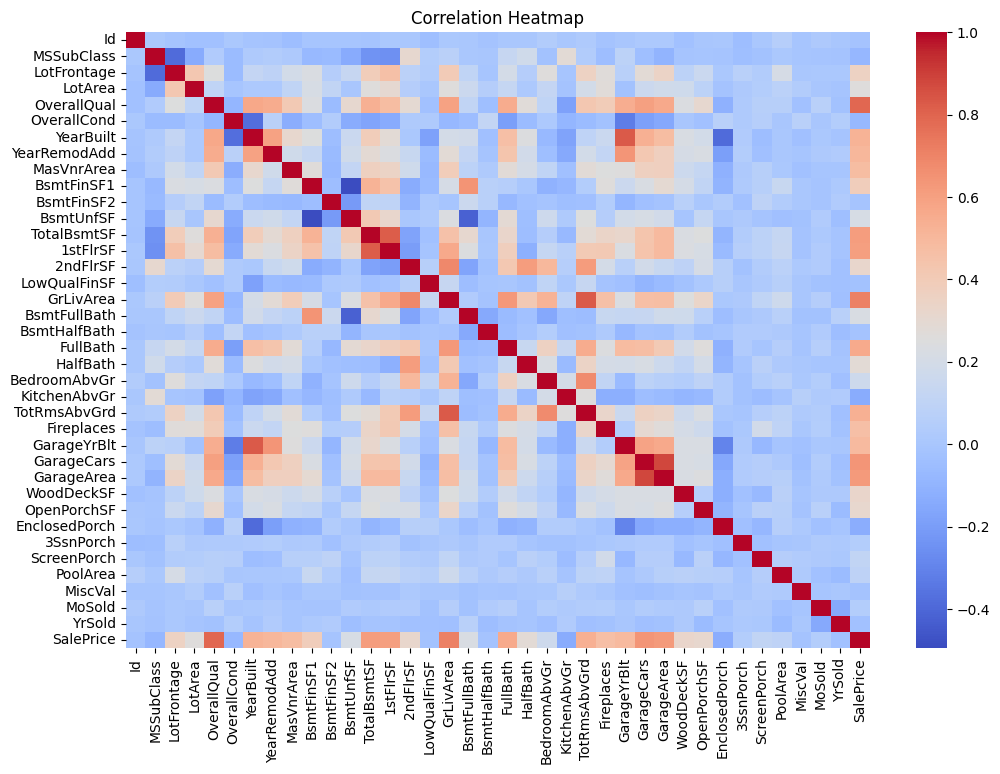

In [ ]:
plt.figure(figsize=(12,8))

corr=df.corr(numeric_only=True)

sns.heatmap(corr, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.savefig(viz_path+"correlation_heatmap.png")

plt.show()

Scatter Plot (Important Feature vs Price)--using GrLivArea

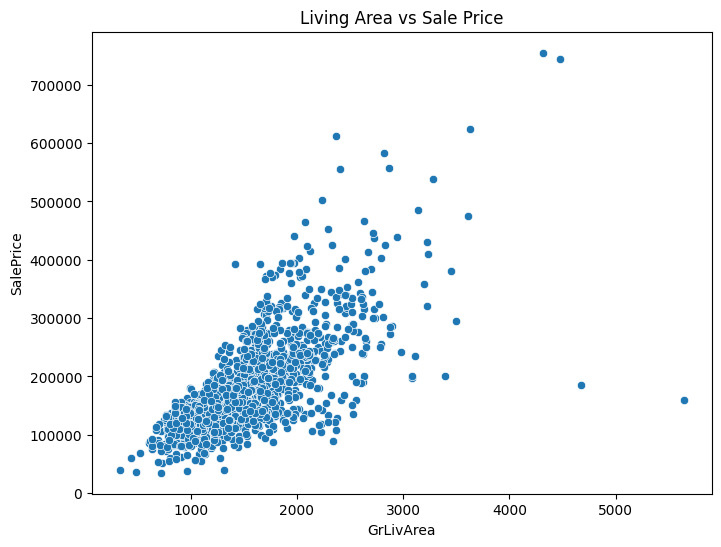

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(x=df["GrLivArea"],y=df["SalePrice"])

plt.title("Living Area vs Sale Price")

plt.savefig(viz_path+"scatter_livingarea_price.png")

plt.show()

Data Cleaning

In [ ]:
df=df.select_dtypes(include=[np.number])

df=df.dropna()

Check

In [ ]:
df.isnull().sum()

,0
Id,0
MSSubClass,0
LotFrontage,0
LotArea,0
OverallQual,0
OverallCond,0
YearBuilt,0
YearRemodAdd,0
MasVnrArea,0
BsmtFinSF1,0


Feature Selection

In [ ]:
X=df.drop("SalePrice",axis=1)

y=df["SalePrice"]

Train Test Split

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

Train Linear Regression Model

In [ ]:
model=LinearRegression()

model.fit(X_train,y_train)

LinearRegression()

Predictions

In [ ]:
predictions=model.predict(X_test)

Model Evaluation
Mean Squared Error

In [ ]:
mse=mean_squared_error(y_test,predictions)

print("MSE:",mse)

MSE: 1591724600.576844


R² Score
Coefficient of Determination

In [ ]:
r2=r2_score(y_test,predictions)

print("R2 Score:",r2)

R2 Score: 0.7981919836405682


Regression Plot

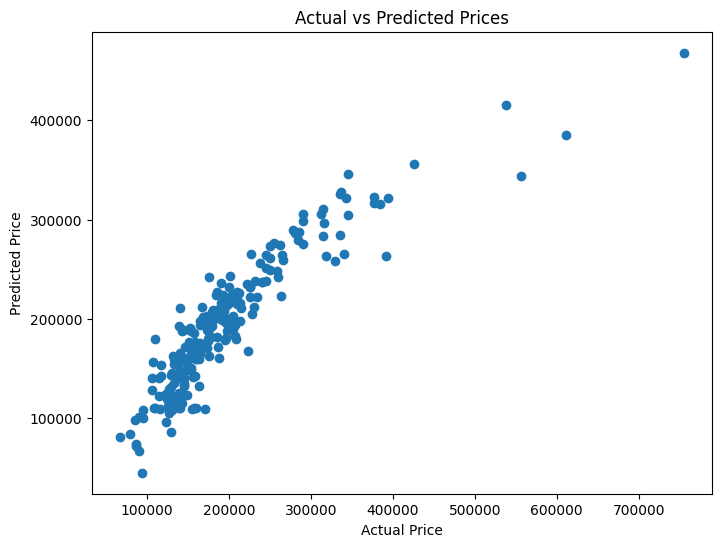

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test,predictions)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.savefig(viz_path+"actual_vs_predicted.png")

plt.show()

Residual Plot

In [ ]:
residuals=y_test-predictions

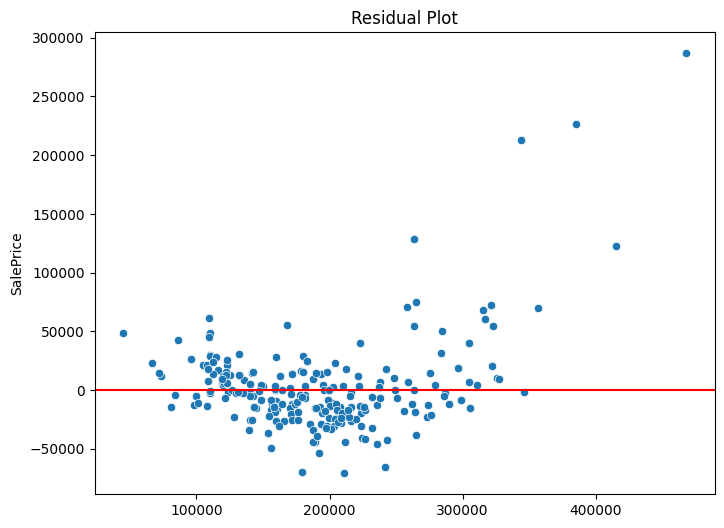

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(x=predictions,y=residuals)

plt.axhline(0,color='red')

plt.title("Residual Plot")

plt.savefig(viz_path+"residual_plot.png")

plt.show()

Error Distribution

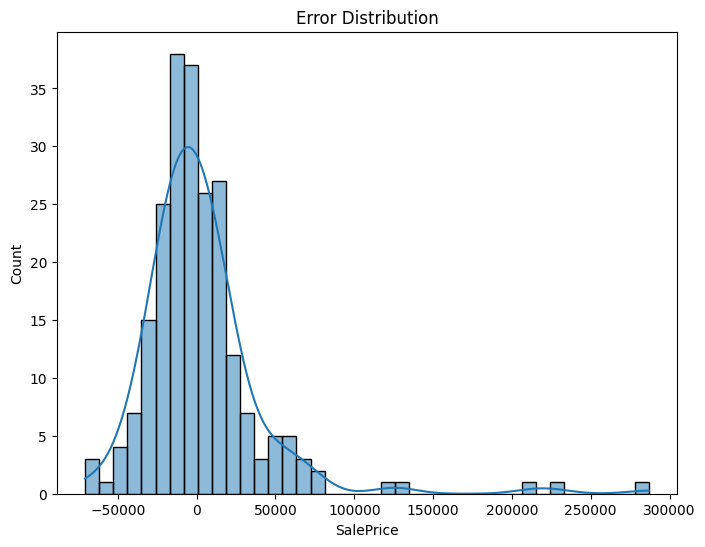

In [ ]:
plt.figure(figsize=(8,6))

sns.histplot(residuals,bins=40,kde=True)

plt.title("Error Distribution")

plt.savefig(viz_path+"error_distribution.png")

plt.show()

Processed Dataset

In [ ]:
df.to_csv(processed_path,index=False)

Model Accuracy (Evaluation Metrics)

R² Score (Model Accuracy Indicator)

RMSE (Root Mean Squared Error)

MAE (Mean Absolute Error)

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2 = r2_score(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, predictions)

print("R2 Score:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

R2 Score: 0.7981919836405682
RMSE: 39896.42340582479
MAE: 23643.51169437096


Actual vs Predicted with regression line

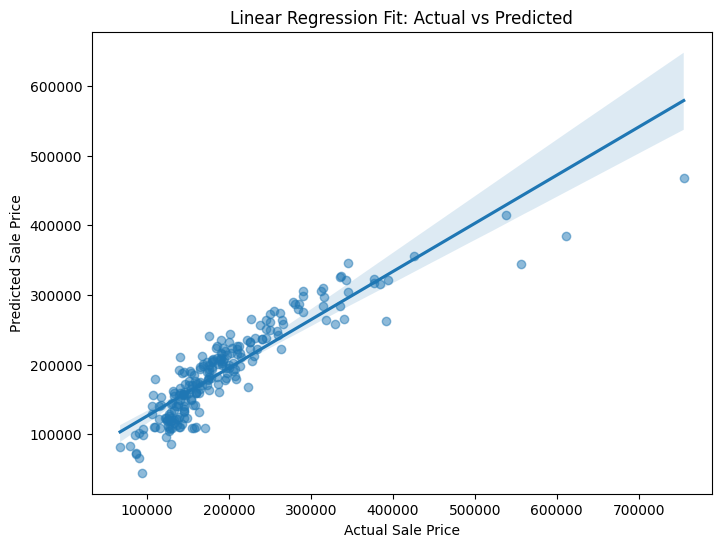

In [ ]:
plt.figure(figsize=(8,6))

sns.regplot(x=y_test, y=predictions, scatter_kws={"alpha":0.5})

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Linear Regression Fit: Actual vs Predicted")

plt.savefig(viz_path+"linear_regression_fit.png")

plt.show()